<a href="https://colab.research.google.com/github/AliefReefandi/Practical-Statistics-for-Data-Scientists/blob/main/Chapter_4_%E2%80%94_Regression_and_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 4 — Regression and Prediction

Chapter 4 membahas regression sebagai metode untuk memahami hubungan antara variabel dan melakukan prediction terhadap suatu nilai berdasarkan predictor yang tersedia.

# 1. Tujuan Pembelajaran

Setelah mempelajari chapter ini, dapat dipahami:

- Simple Linear Regression
- Multiple Linear Regression
- Prediction dan Residual
- Model Evaluation
- Cross-Validation
- Factor Variables
- Multicollinearity
- Confounding Variables
- Interaction
- Regression Diagnostics
- Polynomial Regression
- Spline Regression

# 2. Ringkasan Chapter

Regression digunakan untuk memodelkan hubungan antara sebuah **response variable (Y)** dengan satu atau lebih **predictor variables (X)**.

Secara sederhana:

**Predictor → Regression Model → Prediction**

Contohnya, harga rumah dapat diprediksi berdasarkan luas rumah, jumlah kamar, jumlah kamar mandi, dan kualitas bangunan.

Chapter ini dimulai dari simple linear regression kemudian berkembang menjadi multiple linear regression dan berbagai teknik untuk mengevaluasi serta memperbaiki model.

## 3 Konsep Teoritis

## 3.1 Simple Linear Regression

Simple Linear Regression digunakan untuk melihat hubungan antara satu predictor dan satu response variable.

Persamaan dasarnya:

**Y = b₀ + b₁X + e**

Keterangan:

- **Y** = response variable
- **X** = predictor
- **b₀** = intercept
- **b₁** = coefficient
- **e** = error



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

data = pd.DataFrame({
    'Hours': [1, 2, 3, 4, 5, 6],
    'Score': [50, 55, 65, 70, 78, 85]
})

X = data[['Hours']]
y = data['Score']

model = LinearRegression()
model.fit(X, y)

print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_[0])

Intercept: 42.266666666666666
Coefficient: 7.114285714285716


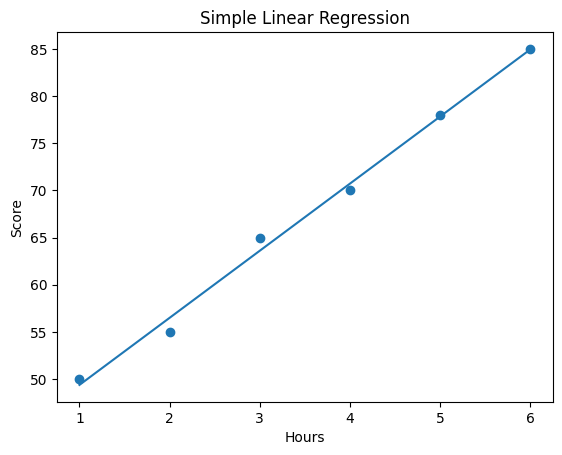

In [2]:
plt.scatter(data['Hours'], data['Score'])

plt.plot(
    data['Hours'],
    model.predict(X)
)

plt.xlabel('Hours')
plt.ylabel('Score')
plt.title('Simple Linear Regression')

plt.show()

### Analisis

Coefficient menunjukkan perubahan pada Y ketika X berubah satu unit.

## 3.2 Fitted Values dan Residuals

**Fitted value** adalah nilai yang diprediksi oleh model.

**Residual** adalah selisih antara nilai aktual dan nilai prediksi.

Rumus sederhana:

**Residual = Actual Value − Predicted Value**



In [3]:
predicted = model.predict(X)

data['Predicted'] = predicted
data['Residual'] = data['Score'] - data['Predicted']

data

,Hours,Score,Predicted,Residual
0,1,50,49.380952,0.619048
1,2,55,56.495238,-1.495238
2,3,65,63.609524,1.390476
3,4,70,70.723810,-0.723810
4,5,78,77.838095,0.161905
5,6,85,84.952381,0.047619


Analisis
Residual digunakan untuk melihat seberapa jauh prediction model dari data sebenarnya.

## 3.3 Multiple Linear Regression

Multiple Linear Regression menggunakan lebih dari satu predictor.

Persamaannya:

**Y = b₀ + b₁X₁ + b₂X₂ + ... + bₚXₚ + e**

Contohnya, harga rumah dapat diprediksi menggunakan:

- luas rumah
- luas tanah
- jumlah kamar
- jumlah kamar mandi
- kualitas bangunan

Buku menggunakan data **King County Housing** sebagai contoh multiple linear regression. :contentReference[oaicite:1]{index=1}



### Dataset House

Pada bagian ini digunakan dataset House yang digunakan dalam contoh multiple linear regression pada buku.

Dataset berisi informasi mengenai harga rumah dan beberapa karakteristik rumah seperti luas bangunan, luas tanah, jumlah kamar mandi, jumlah kamar, dan kualitas bangunan.

In [13]:
# Membuat kelompok ZIP berdasarkan residual harga rumah

predictors = [
    'SqFtTotLiving',
    'SqFtLot',
    'Bathrooms',
    'Bedrooms',
    'BldgGrade'
]

outcome = 'AdjSalePrice'

house_lm = LinearRegression()
house_lm.fit(house[predictors], house[outcome])

zip_residuals = pd.DataFrame({
    'ZipCode': house['ZipCode'],
    'residual': house[outcome] - house_lm.predict(house[predictors])
})

zip_groups = pd.DataFrame([
    {
        'ZipCode': zipCode,
        'count': len(x),
        'median_residual': x.residual.median()
    }
    for zipCode, x in zip_residuals.groupby('ZipCode')
]).sort_values('median_residual')

zip_groups['cum_count'] = np.cumsum(zip_groups['count'])

zip_groups['ZipGroup'] = pd.qcut(
    zip_groups['cum_count'],
    5,
    labels=False,
    retbins=False
)

to_join = zip_groups[['ZipCode', 'ZipGroup']].set_index('ZipCode')

house = house.join(to_join, on='ZipCode')

house['ZipGroup'] = house['ZipGroup'].astype('category')

house[['ZipCode', 'ZipGroup']].head()

,ZipCode,ZipGroup
1,98002,2
2,98166,2
3,98166,2
4,98168,2
5,98168,2


In [6]:
import pandas as pd

url = "https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/house_sales.csv"

house = pd.read_csv(url, sep='\t')

house.head()

,DocumentDate,SalePrice,PropertyID,PropertyType,ym,zhvi_px,zhvi_idx,AdjSalePrice,NbrLivingUnits,SqFtLot,...,Bathrooms,Bedrooms,BldgGrade,YrBuilt,YrRenovated,TrafficNoise,LandVal,ImpsVal,ZipCode,NewConstruction
1,2014-09-16,280000,1000102,Multiplex,2014-09-01,405100,0.930836,300805.0,2,9373,...,3.00,6,7,1991,0,0,70000,229000,98002,False
2,2006-06-16,1000000,1200013,Single Family,2006-06-01,404400,0.929228,1076162.0,1,20156,...,3.75,4,10,2005,0,0,203000,590000,98166,True
3,2007-01-29,745000,1200019,Single Family,2007-01-01,425600,0.977941,761805.0,1,26036,...,1.75,4,8,1947,0,0,183000,275000,98166,False
4,2008-02-25,425000,2800016,Single Family,2008-02-01,418400,0.961397,442065.0,1,8618,...,3.75,5,7,1966,0,0,104000,229000,98168,False
5,2013-03-29,240000,2800024,Single Family,2013-03-01,351600,0.807904,297065.0,1,8620,...,1.75,4,7,1948,0,0,104000,205000,98168,False


In [7]:
from sklearn.linear_model import LinearRegression

predictors = [
    'SqFtTotLiving',
    'SqFtLot',
    'Bathrooms',
    'Bedrooms',
    'BldgGrade'
]

outcome = 'AdjSalePrice'

X = house[predictors]
y = house[outcome]

model = LinearRegression()
model.fit(X, y)

print("Intercept:", model.intercept_)

for name, coef in zip(predictors, model.coef_):
    print(name, ":", coef)

Intercept: -521871.36818828376
SqFtTotLiving : 228.83060360240793
SqFtLot : -0.06046682065307607
Bathrooms : -19442.840398321066
Bedrooms : -47769.95518521438
BldgGrade : 106106.96307898081


### Analisis

Dengan beberapa predictor, model dapat menggunakan lebih banyak informasi untuk menjelaskan atau memprediksi response variable.

## 3.4 Assessing the Model

Model regression perlu dievaluasi untuk mengetahui seberapa baik prediction yang dihasilkan.

Salah satu metric yang dibahas adalah:

**RMSE (Root Mean Squared Error)**

RMSE menunjukkan rata-rata besar error prediction dalam bentuk yang sesuai dengan satuan response variable.

Selain RMSE, regression juga sering melihat **R-squared (R²)** untuk mengetahui proporsi variasi response yang dijelaskan oleh model. :contentReference[oaicite:3]{index=3}

In [8]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

prediction = model.predict(X)

rmse = np.sqrt(mean_squared_error(y, prediction))
r2 = r2_score(y, prediction)

print("RMSE:", rmse)
print("R²:", r2)

RMSE: 261220.19743696266
R²: 0.5405875253381902


## 3.5 Cross-Validation

Cross-Validation digunakan untuk mengevaluasi model menggunakan pembagian data sehingga performa model tidak hanya dinilai dari data yang digunakan untuk training.



In [9]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

prediction = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, prediction))

print("Test RMSE:", rmse)

Test RMSE: 272593.8210996234


### Analisis

Tujuannya adalah mendapatkan gambaran yang lebih baik mengenai kemampuan model ketika digunakan pada data yang belum pernah dilihat sebelumnya.

## 3.6 Factor Variables

Factor variables atau categorical variables memiliki nilai dalam bentuk kategori.

Contohnya:

- PropertyType = Single Family
- PropertyType = Townhouse
- PropertyType = Multiplex

Regression membutuhkan input numerik, sehingga categorical variable biasanya diubah menjadi **dummy variables**.

Buku menggunakan `pd.get_dummies()` untuk melakukan proses tersebut. :contentReference[oaicite:4]{index=4}

In [10]:
dummy_data = pd.DataFrame({
    'PropertyType': [
        'Single Family',
        'Townhouse',
        'Multiplex',
        'Single Family'
    ]
})

pd.get_dummies(
    dummy_data['PropertyType'],
    drop_first=True
)


,Single Family,Townhouse
0,True,False
1,False,True
2,False,False
3,True,False


## 3.7 Multicollinearity

Multicollinearity terjadi ketika predictor variables memiliki hubungan yang sangat kuat satu sama lain.

Contohnya:

**House Size ↔ Living Area**

Jika dua predictor hampir memberikan informasi yang sama, coefficient regression dapat menjadi tidak stabil.



In [11]:
correlation = data.corr(numeric_only=True)

print(correlation)

                  Hours     Score     Predicted      Residual
Hours      1.000000e+00  0.997131  1.000000e+00 -3.382953e-15
Score      9.971307e-01  1.000000  9.971307e-01  7.569889e-02
Predicted  1.000000e+00  0.997131  1.000000e+00 -3.397954e-15
Residual  -3.382953e-15  0.075699 -3.397954e-15  1.000000e+00


### Analisis

Multicollinearity perlu diperhatikan karena dapat membuat interpretasi coefficient menjadi sulit. Buku menyarankan menghindari predictor yang redundant dalam regression. :contentReference[oaicite:5]{index=5}

## 3.8 Confounding Variables

Confounding variable adalah variabel penting yang tidak dimasukkan ke dalam model sehingga hubungan antara predictor dan response dapat disalahartikan.

Pada contoh harga rumah, **location** merupakan faktor penting yang dapat memengaruhi harga rumah.

Jika location tidak dimasukkan ke model, coefficient predictor lain dapat mencerminkan pengaruh location secara tidak langsung. :contentReference[oaicite:6]{index=6}

### Analisis

Oleh karena itu, pemilihan predictor harus mempertimbangkan faktor yang relevan terhadap masalah yang dianalisis.

## 3.9 Interactions

Interaction terjadi ketika pengaruh suatu predictor terhadap response bergantung pada predictor lainnya.

Contoh pada data rumah:

**Ukuran rumah × lokasi**

Pengaruh tambahan luas rumah terhadap harga dapat berbeda tergantung lokasi rumah.

In [14]:
import statsmodels.formula.api as smf

model_interaction = smf.ols(
    'AdjSalePrice ~ SqFtTotLiving * ZipGroup',
    data=house
).fit()

print(model_interaction.summary())

                            OLS Regression Results                            
Dep. Variable:           AdjSalePrice   R-squared:                       0.631
Model:                            OLS   Adj. R-squared:                  0.631
Method:                 Least Squares   F-statistic:                     4305.
Date:                Tue, 29 Sep 2026   Prob (F-statistic):               0.00
Time:                        11:39:50   Log-Likelihood:            -3.1269e+05
No. Observations:               22687   AIC:                         6.254e+05
Df Residuals:                   22677   BIC:                         6.255e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

### Analisis

Interaction membantu model menggambarkan hubungan yang lebih kompleks antara predictor dan response.

## 3.10 Regression Diagnostics

Regression diagnostics digunakan untuk melihat masalah pada model.

Beberapa hal yang perlu diperhatikan:

- **Outliers** → data yang jauh dari pola umum.
- **Influential Values** → data yang sangat memengaruhi model.
- **Heteroskedasticity** → variasi residual tidak konstan.
- **Non-Normality** → residual tidak mengikuti distribusi yang diharapkan.

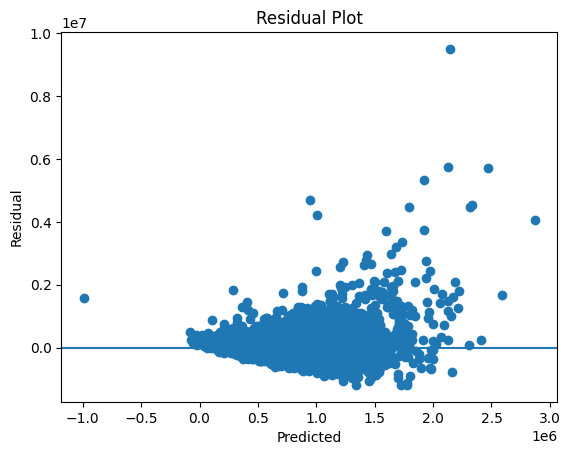

In [15]:
import matplotlib.pyplot as plt

residuals = y - model.predict(X)

plt.scatter(model.predict(X), residuals)

plt.axhline(0)

plt.xlabel('Predicted')
plt.ylabel('Residual')
plt.title('Residual Plot')

plt.show()

### Analisis

Diagnostics membantu mengetahui apakah model regression sudah memberikan representasi yang sesuai terhadap data.

## 3.11 Polynomial Regression

Polynomial Regression digunakan ketika hubungan antara predictor dan response tidak cukup dijelaskan oleh garis lurus.

Contoh quadratic:

**Y = b₀ + b₁X + b₂X² + e**

Buku memberikan contoh polynomial regression menggunakan `SqFtTotLiving` pada data rumah. :contentReference[oaicite:8]{index=8}

In [16]:
import statsmodels.formula.api as smf

model_poly = smf.ols(
    'AdjSalePrice ~ SqFtTotLiving + I(SqFtTotLiving**2)',
    data=house
).fit()

print(model_poly.summary())

                            OLS Regression Results                            
Dep. Variable:           AdjSalePrice   R-squared:                       0.547
Model:                            OLS   Adj. R-squared:                  0.547
Method:                 Least Squares   F-statistic:                 1.368e+04
Date:                Tue, 29 Sep 2026   Prob (F-statistic):               0.00
Time:                        11:41:00   Log-Likelihood:            -3.1502e+05
No. Observations:               22687   AIC:                         6.300e+05
Df Residuals:                   22684   BIC:                         6.301e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept              3.159e+

### Analisis

Penambahan term seperti X² memungkinkan model menangkap pola yang melengkung.

## 3.12 Splines

Splines merupakan pendekatan untuk memodelkan hubungan nonlinear dengan membentuk beberapa bagian kurva yang tetap tersambung secara smooth.

### Analisis

Splines dapat digunakan ketika hubungan antara predictor dan response memiliki pola nonlinear yang sulit dijelaskan hanya dengan garis lurus.

Buku membahas splines sebagai alternatif terhadap penggunaan polynomial dengan tingkat yang terlalu tinggi.

# 4. Summary dan Kesimpulan

## Summary

Chapter 4 membahas penggunaan regression untuk memahami hubungan antara predictor dan response serta melakukan prediction.

Konsep utama yang dipelajari:

- Simple Linear Regression
- Multiple Linear Regression
- Fitted Values dan Residuals
- RMSE dan R²
- Cross-Validation
- Factor Variables
- Multicollinearity
- Confounding Variables
- Interaction
- Regression Diagnostics
- Polynomial Regression
- Splines

## Kesimpulan

Regression dapat digunakan untuk menjelaskan hubungan antarvariabel dan melakukan prediction.

Namun, membangun model regression tidak hanya tentang mendapatkan prediction. Model juga perlu dievaluasi dan diperiksa terhadap masalah seperti multicollinearity, confounding variables, outliers, dan hubungan nonlinear.

Dengan memahami konsep tersebut, regression dapat digunakan secara lebih tepat untuk menganalisis data dan membuat prediction.